# Building the environment

In [1]:
!git clone https://github.com/niaz1971/ROAD_CRACK_DETECTION.git

Cloning into 'ROAD_CRACK_DETECTION'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 8 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), done.


In [2]:
cd ROAD_CRACK_DETECTION

/content/ROAD_CRACK_DETECTION


In [3]:
!pip install lime kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d rukiyeaydn/road-crack-dataset

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=6f72fc138cc6c5cf6fb98a545a81c64f1d20867412d2cfa5ff434cccfe5f9072
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
Dataset URL: https://www.kaggle.com/datasets/rukiyeaydn/road-crack-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 46.7M/46.7M [00:00<00:00, 76.2MB/s]



In [4]:
!ls

kaggle.json  road-crack-dataset.zip


In [5]:
!unzip -q road-crack-dataset.zip
!rm road-crack-dataset.zip
!rm kaggle.json

In [6]:
# Downloading the libraries
!pip install -q segmentation-models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.7 MB/s eta 0:00:00


In [7]:
# Importing the libraries
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

In [8]:
# Printing the versions
print("TensorFlow:",tf.__version__)
print("NumPy:",np.__version__)

TensorFlow: 2.20.0
NumPy: 2.0.2


In [9]:
!ls

 README.md  'road crack dataset semantic'


# Data Preprocessing

In [10]:
# Defining the paths
TRAIN_PATH="road crack dataset semantic/train"
VALID_PATH="road crack dataset semantic/valid"
IMG_SIZE = 256
BATCH_SIZE=8
EPOCHS=50

In [11]:
# Defining the function to load dataset
def load_dataset(folder,img_size=256):
    images=[]
    masks=[]
    files=os.listdir(folder)
    image_files=[f for f in files if f.endswith(".jpg")]
    for img_file in image_files:
        mask_file = img_file.replace(".jpg","_mask.png")
        img_path = os.path.join(folder,img_file)
        mask_path = os.path.join(folder,mask_file)
        if not os.path.exists(mask_path):
            continue
        image=cv2.imread(img_path)
        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
        image=cv2.resize(image,(img_size,img_size))
        image=image.astype(np.float32)/255.0
        mask=cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
        mask=cv2.resize(mask,(img_size,img_size))
        mask=(mask>0).astype(np.float32)
        mask=np.expand_dims(mask,axis=-1)
        images.append(image)
        masks.append(mask)
    return (np.array(images,dtype=np.float32),np.array(masks,dtype=np.float32))

In [12]:
# Loading the dataset
X_train,y_train=load_dataset(TRAIN_PATH,IMG_SIZE)
X_valid,y_valid=load_dataset(VALID_PATH,IMG_SIZE)
print("Train Images:",X_train.shape)
print("Train Masks:",y_train.shape)
print("Valid Images:",X_valid.shape)
print("Valid Masks:",y_valid.shape)

Train Images: (348, 256, 256, 3)
Train Masks: (348, 256, 256, 1)
Valid Images: (87, 256, 256, 3)
Valid Masks: (87, 256, 256, 1)


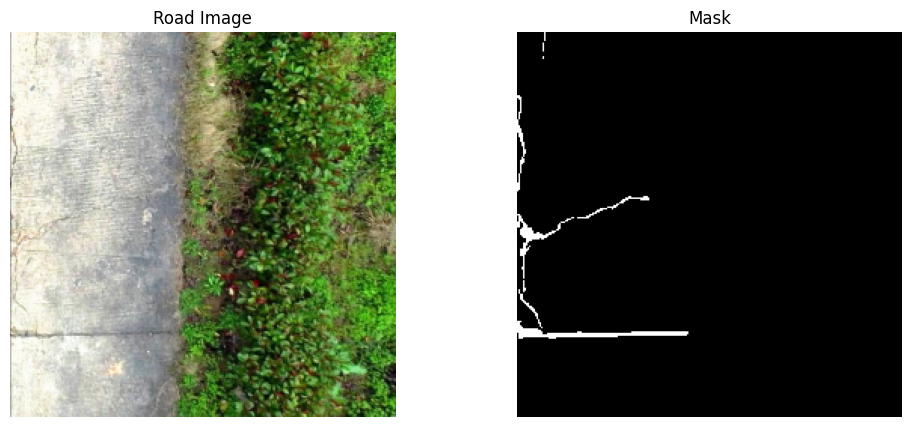

In [13]:
# Visualizing the functions
idx=np.random.randint(0,len(X_train))
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(X_train[idx])
plt.title("Road Image")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(y_train[idx].squeeze(),cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()

# Model Training

In [14]:
# Defining the function for dice coefficient
def dice_coef(y_true,y_pred,smooth=1e-6):
    y_true_f=K.flatten(y_true)
    y_pred_f=K.flatten(y_pred)
    intersection=K.sum(y_true_f*y_pred_f)
    return (2.0*intersection+smooth)/(K.sum(y_true_f)+K.sum(y_pred_f)+smooth)

In [15]:
# Defining the loss function
def dice_loss(y_true,y_pred):
    return 1-dice_coef(y_true,y_pred)
def bce_dice_loss(y_true,y_pred):
    bce=tf.keras.losses.binary_crossentropy(y_true,y_pred)
    return bce+dice_loss(y_true,y_pred)

In [16]:
# Defining the Convolution Block
def conv_block(x,filters):
    x=Conv2D(filters,3,padding="same")(x)
    x=BatchNormalization()(x)
    x=Activation("relu")(x)
    x=Conv2D(filters,3,padding="same")(x)
    x=BatchNormalization()(x)
    x=Activation("relu")(x)
    return x

In [17]:
# Developing the U-Net Architecture
def build_unet(input_shape):
    inputs=Input(input_shape)
    c1=conv_block(inputs,64)
    p1=MaxPooling2D()(c1)
    c2=conv_block(p1,128)
    p2=MaxPooling2D()(c2)
    c3=conv_block(p2,256)
    p3=MaxPooling2D()(c3)
    c4=conv_block(p3,512)
    p4=MaxPooling2D()(c4)
    bn=conv_block(p4,1024)
    u1=Conv2DTranspose(512,2,strides=2,padding="same")(bn)
    u1=Concatenate()([u1,c4])
    c5=conv_block(u1,512)
    u2=Conv2DTranspose(256,2,strides=2,padding="same")(c5)
    u2=Concatenate()([u2,c3])
    c6=conv_block(u2,256)
    u3=Conv2DTranspose(128,2,strides=2,padding="same")(c6)
    u3=Concatenate()([u3,c2])
    c7=conv_block(u3,128)
    u4=Conv2DTranspose(64,2,strides=2,padding="same")(c7)
    u4=Concatenate()([u4,c1])
    c8=conv_block(u4,64)
    outputs=Conv2D(1,1,activation="sigmoid")(c8)
    model=Model(inputs,outputs)
    return model

In [18]:
# Building the model
model=build_unet((IMG_SIZE,IMG_SIZE, 3))
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,055,297 (118.47 MB)

 Trainable params: 31,043,521 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

In [19]:
# Compiling the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss=bce_dice_loss,
    metrics=[dice_coef]
)

In [20]:
# Building the callbacks
callbacks=[
    tf.keras.callbacks.ModelCheckpoint("best_unet.keras",save_best_only=True,monitor="val_loss"),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss",patience=8,restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",factor=0.5,patience=3,verbose=1)
]

In [21]:
# Training the model
history=model.fit(
    X_train,
    y_train,
    validation_data=(X_valid,y_valid),
    batch_size=BATCH_SIZE,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - dice_coef: 0.1132 - loss: 1.3727 - val_dice_coef: 0.0982 - val_loss: 1.4223 - learning_rate: 1.0000e-04
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 27s 615ms/step - dice_coef: 0.1960 - loss: 1.0180 - val_dice_coef: 0.1061 - val_loss: 1.2262 - learning_rate: 1.0000e-04
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 693ms/step - dice_coef: 0.2521 - loss: 0.9197 - val_dice_coef: 0.1055 - val_loss: 1.1528 - learning_rate: 1.0000e-04
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 24s 555ms/step - dice_coef: 0.2933 - loss: 0.8624 - val_dice_coef: 0.1035 - val_loss: 1.1635 - learning_rate: 1.0000e-04
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 31s 702ms/step - dice_coef: 0.3312 - loss: 0.8065 - val_dice_coef: 0.0883 - val_loss: 1.1277 - learning_rate: 1.0000e-04


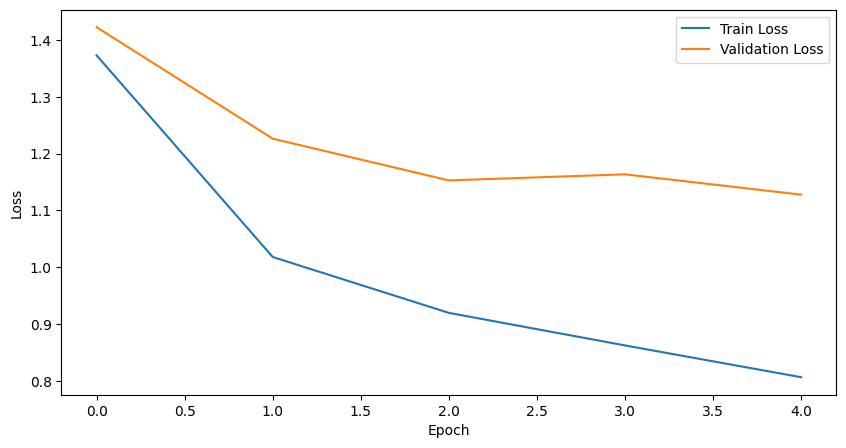

In [22]:
# Plotting the training loss
plt.figure(figsize=(10,5))
plt.plot(history.history["loss"],label="Train Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Examining the prediction

In [23]:
# Making predictions
predictions=model.predict(X_valid[:5])
predictions=(predictions > 0.5).astype(np.float32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 16s 16s/step


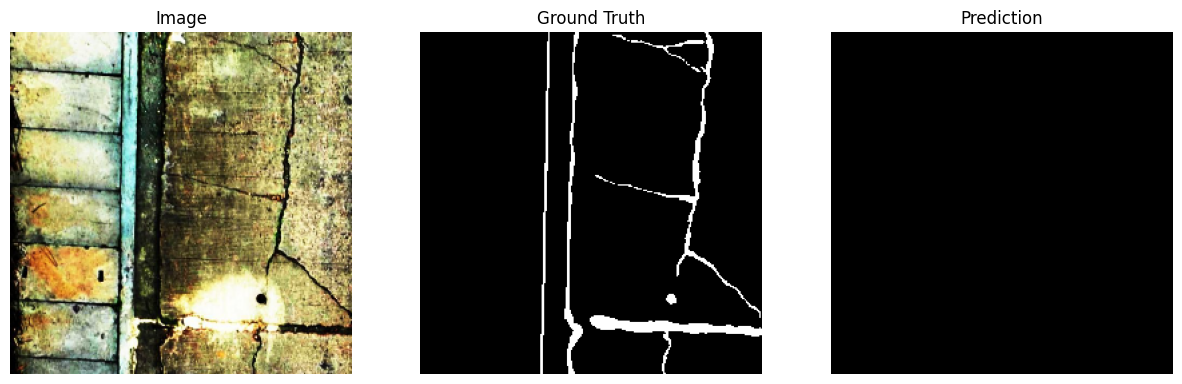

In [24]:
# Visualizing the predictions
idx=0
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(X_valid[idx])
plt.title("Image")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(y_valid[idx].squeeze(),cmap="gray")
plt.title("Ground Truth")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(predictions[idx].squeeze(),cmap="gray")
plt.title("Prediction")
plt.axis("off")
plt.show()

# Building the file

In [25]:
# Saving the model
model.save("road_crack_unet.keras")